# QAOA Use Case (MaxCut on Triangle, p=1)

This notebook compiles a parameterized QAOA model with the transformation pipeline, executes it with Qiskit, and runs a simple classical optimization loop over `(gamma, beta)` parameters.

This use-case follows the idea in: https://qiskit.qotlabs.org/docs/tutorials/quantum-approximate-optimization-algorithm

## Workflow

1. Load a parameterized QAOA model JSON.
2. Update model parameters and send each candidate to `POST /debug/compile`.
3. Execute each candidate circuit with Qiskit Aer.
4. Maximize expected MaxCut value with a coordinate-search loop.

In [1]:
import copy
import json
import math
from pathlib import Path

import requests
from IPython.display import display
from qiskit import QuantumCircuit, qasm3, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [ ]:
BASE_URL = "http://localhost:8000"
COMPILE_URL = f"{BASE_URL}/debug/compile"

USE_CASE_DIR = Path.cwd()
if not (USE_CASE_DIR / "qaoa_maxcut_triangle_p1.json").exists():
    USE_CASE_DIR = Path("/03-qaoa")

MODEL_PATH = USE_CASE_DIR / "qaoa_maxcut_triangle_p1.json"
BASE_MODEL = json.loads(MODEL_PATH.read_text(encoding="utf-8"))
BASE_MODEL["parameters"]

{'gamma': 0.8, 'beta': 0.7, 'gamma_2': 1.6, 'beta_2': 1.4}

In [3]:
def build_payload(gamma: float, beta: float) -> dict:
    payload = copy.deepcopy(BASE_MODEL)
    payload.setdefault("parameters", {})
    payload["parameters"]["gamma"] = float(gamma)
    payload["parameters"]["beta"] = float(beta)
    payload["parameters"]["gamma_2"] = float(2.0 * gamma)
    payload["parameters"]["beta_2"] = float(2.0 * beta)
    return payload


def compile_payload(payload: dict) -> str:
    response = requests.post(COMPILE_URL, json=payload, timeout=120)
    response.raise_for_status()

    content_type = response.headers.get("content-type", "")
    if "application/json" in content_type:
        raise RuntimeError(f"Unexpected JSON response: {response.json()}")

    return response.text

In [4]:
def circuit_from_qasm(qasm_text: str) -> QuantumCircuit:
    qc = qasm3.loads(qasm_text)
    return qc


def cut_value(bitstring: str) -> int:
    compact = bitstring.replace(" ", "")
    bits = [int(bit) for bit in compact[::-1]]
    edges = [(0, 1), (1, 2), (0, 2)]
    return sum(1 for i, j in edges if bits[i] != bits[j])


def expected_cut_value(counts: dict[str, int]) -> float:
    total_shots = sum(counts.values())
    weighted_sum = sum(cut_value(state) * shots for state, shots in counts.items())
    return weighted_sum / total_shots


Initial gamma=0.8000, beta=0.7000, score=0.0527


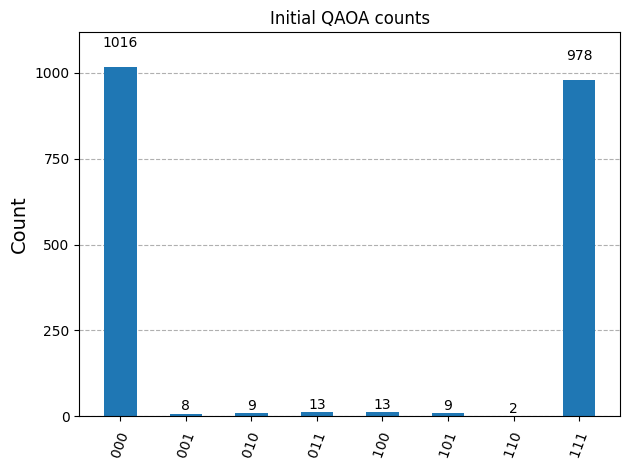

In [5]:
simulator = AerSimulator()


def run_candidate(gamma: float, beta: float, shots: int = 2048) -> tuple[float, dict[str, int], str]:
    payload = build_payload(gamma, beta)
    qasm_text = compile_payload(payload)
    qc = circuit_from_qasm(qasm_text)
    tqc = transpile(qc, simulator)
    counts = simulator.run(tqc, shots=shots).result().get_counts()
    score = expected_cut_value(counts)
    return score, counts, qasm_text


initial_gamma = float(BASE_MODEL["parameters"]["gamma"])
initial_beta = float(BASE_MODEL["parameters"]["beta"])
initial_score, initial_counts, initial_qasm = run_candidate(initial_gamma, initial_beta)

print(f"Initial gamma={initial_gamma:.4f}, beta={initial_beta:.4f}, score={initial_score:.4f}")
display(plot_histogram(initial_counts, title="Initial QAOA counts"))


## Classical Optimization Loop

A small coordinate-search optimizer evaluates neighboring parameter points around the current best `(gamma, beta)` pair and keeps improvements.

In [6]:
gamma = initial_gamma
beta = initial_beta
step_gamma = 0.5
step_beta = 0.5

best_gamma = gamma
best_beta = beta
best_score = initial_score
best_counts = initial_counts
best_qasm = initial_qasm

history: list[dict] = []
max_iterations = 8

for iteration in range(1, max_iterations + 1):
    candidates = [
        (gamma, beta),
        (min(math.pi, gamma + step_gamma), beta),
        (max(0.0, gamma - step_gamma), beta),
        (gamma, min(math.pi, beta + step_beta)),
        (gamma, max(0.0, beta - step_beta)),
    ]

    local_best = None
    for cand_gamma, cand_beta in candidates:
        score, counts, qasm_text = run_candidate(cand_gamma, cand_beta)
        candidate_record = {
            "gamma": cand_gamma,
            "beta": cand_beta,
            "score": score,
            "counts": counts,
            "qasm": qasm_text,
        }
        if local_best is None or candidate_record["score"] > local_best["score"]:
            local_best = candidate_record

    assert local_best is not None
    gamma = local_best["gamma"]
    beta = local_best["beta"]

    improved = local_best["score"] > best_score
    if improved:
        best_gamma = local_best["gamma"]
        best_beta = local_best["beta"]
        best_score = local_best["score"]
        best_counts = local_best["counts"]
        best_qasm = local_best["qasm"]
    else:
        step_gamma *= 0.7
        step_beta *= 0.7

    history.append({
        "iteration": iteration,
        "gamma": gamma,
        "beta": beta,
        "score": local_best["score"],
        "best_score": best_score,
        "step_gamma": step_gamma,
        "step_beta": step_beta,
    })

    print(
        f"iter={iteration:02d} gamma={gamma:.4f} beta={beta:.4f} "
        f"score={local_best['score']:.4f} best={best_score:.4f} "
        f"step_gamma={step_gamma:.4f} step_beta={step_beta:.4f}"
    )

iter=01 gamma=1.3000 beta=0.7000 score=1.3340 best=1.3340 step_gamma=0.5000 step_beta=0.5000
iter=02 gamma=1.3000 beta=0.2000 score=1.9150 best=1.9150 step_gamma=0.5000 step_beta=0.5000
iter=03 gamma=1.3000 beta=0.2000 score=1.9062 best=1.9150 step_gamma=0.3500 step_beta=0.3500
iter=04 gamma=1.3000 beta=0.2000 score=1.9033 best=1.9150 step_gamma=0.2450 step_beta=0.2450
iter=05 gamma=1.3000 beta=0.2000 score=1.9346 best=1.9346 step_gamma=0.2450 step_beta=0.2450
iter=06 gamma=1.3000 beta=0.2000 score=1.9111 best=1.9346 step_gamma=0.1715 step_beta=0.1715
iter=07 gamma=1.3000 beta=0.3715 score=1.9727 best=1.9727 step_gamma=0.1715 step_beta=0.1715
iter=08 gamma=1.3000 beta=0.3715 score=1.9766 best=1.9766 step_gamma=0.1715 step_beta=0.1715


{'iteration': 1, 'gamma': 1.3, 'beta': 0.7, 'score': 1.333984375, 'best_score': 1.333984375, 'step_gamma': 0.5, 'step_beta': 0.5}
{'iteration': 2, 'gamma': 1.3, 'beta': 0.19999999999999996, 'score': 1.9150390625, 'best_score': 1.9150390625, 'step_gamma': 0.5, 'step_beta': 0.5}
{'iteration': 3, 'gamma': 1.3, 'beta': 0.19999999999999996, 'score': 1.90625, 'best_score': 1.9150390625, 'step_gamma': 0.35, 'step_beta': 0.35}
{'iteration': 4, 'gamma': 1.3, 'beta': 0.19999999999999996, 'score': 1.9033203125, 'best_score': 1.9150390625, 'step_gamma': 0.24499999999999997, 'step_beta': 0.24499999999999997}
{'iteration': 5, 'gamma': 1.3, 'beta': 0.19999999999999996, 'score': 1.9345703125, 'best_score': 1.9345703125, 'step_gamma': 0.24499999999999997, 'step_beta': 0.24499999999999997}
{'iteration': 6, 'gamma': 1.3, 'beta': 0.19999999999999996, 'score': 1.9111328125, 'best_score': 1.9345703125, 'step_gamma': 0.17149999999999996, 'step_beta': 0.17149999999999996}
{'iteration': 7, 'gamma': 1.3, 'beta'

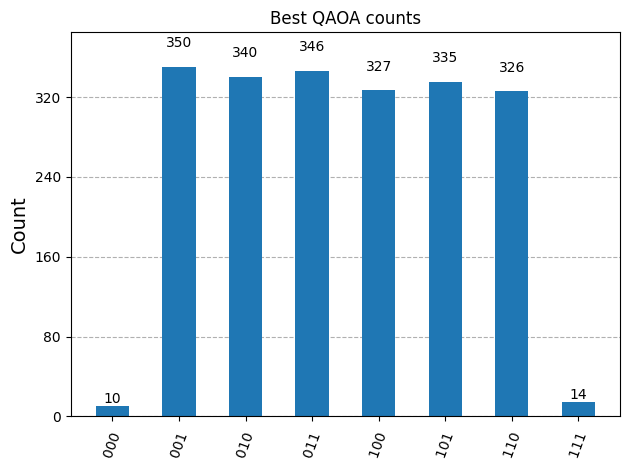

In [7]:
for row in history:
    print(row)

print("\nBest parameters:")
print(f"gamma={best_gamma:.6f}, beta={best_beta:.6f}, expected cut={best_score:.6f}")
display(plot_histogram(best_counts, title="Best QAOA counts"))

In [8]:
print("Best candidate OpenQASM (first 60 lines):")
print("\n".join(best_qasm.splitlines()[:60]))

Best candidate OpenQASM (first 60 lines):
OPENQASM 3.1;
include "stdgates.inc";
qubit[3] leqo_reg;
/* Start node q0 */
let leqo_677c62829b2f503e829851dd8911e48a_literal = leqo_reg[{0}];
@leqo.output 0
let leqo_677c62829b2f503e829851dd8911e48a_out = leqo_677c62829b2f503e829851dd8911e48a_literal;
/* End node q0 */
/* Start node q1 */
let leqo_64bc2e5f2880544d8c66cf84e4146b48_literal = leqo_reg[{1}];
@leqo.output 0
let leqo_64bc2e5f2880544d8c66cf84e4146b48_out = leqo_64bc2e5f2880544d8c66cf84e4146b48_literal;
/* End node q1 */
/* Start node q2 */
let leqo_d27ae4e9247b51b7a31ef707aa4284d1_literal = leqo_reg[{2}];
@leqo.output 0
let leqo_d27ae4e9247b51b7a31ef707aa4284d1_out = leqo_d27ae4e9247b51b7a31ef707aa4284d1_literal;
/* End node q2 */
/* Start node h0 */
@leqo.input 0
let leqo_f45af023808a5cf79d21fba41ac26560_q0 = leqo_reg[{0}];
h leqo_f45af023808a5cf79d21fba41ac26560_q0;
@leqo.output 0
let leqo_f45af023808a5cf79d21fba41ac26560_q0_out = leqo_f45af023808a5cf79d21fba41ac26560_q0;
/* End n

For the triangle graph, the maximum cut value is `2`.
A successful optimization should move the expected value toward this upper bound.